# **Weight** **Prediction** **Model**
###In this ML Model, User enter their Height and model predicts its Weight

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/1st/HeightWeight.csv")
df.tail()

,Index,Height(Inches),Weight(Pounds)
24995,24996,69.50215,118.0312
24996,24997,64.54826,120.1932
24997,24998,64.69855,118.2655
24998,24999,67.52918,132.2682
24999,25000,68.87761,124.8742


In [27]:
df.isnull().sum()

,0
Index,0
Height(Inches),0
Weight(Pounds),0


In [28]:
# Converting Units

df["Height(Feet)"] = df["Height(Inches)"] / 12       #Inches to Feet
df["Weight(Kg)"] = df["Weight(Pounds)"] * 0.453592   #Pounds to kg
df.drop(["Height(Inches)", "Index", "Weight(Pounds)"], axis=1, inplace=True)  #Remove extra features

df.tail()

,Height(Feet),Weight(Kg)
24995,5.791846,53.538008
24996,5.379022,54.518674
24997,5.391546,53.644285
24998,5.627432,59.995797
24999,5.739801,56.641938


In [29]:
df

,Height(Feet),Weight(Kg)
0,5.481942,51.252494
1,5.959601,61.909547
2,5.783228,69.411778
3,5.684717,64.562199
4,5.648984,65.452010
...,...,...
24995,5.791846,53.538008
24996,5.379022,54.518674
24997,5.391546,53.644285
24998,5.627432,59.995797


In [30]:
#Creating Independent & Dependent Features

x= df[['Height(Feet)']]
y= df['Weight(Kg)']

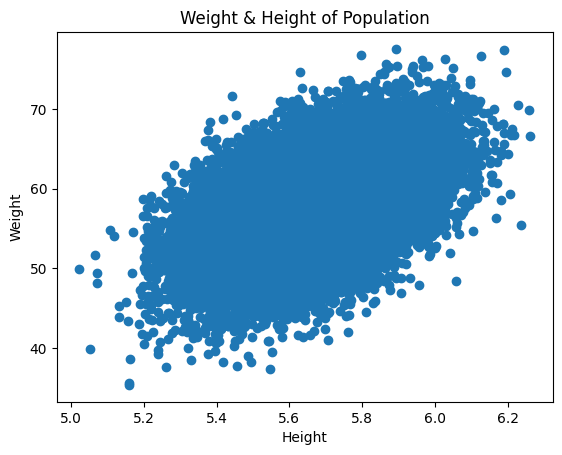

In [31]:
# Data Visualization
plt.scatter(x, y)
plt.xlabel("Height")
plt.ylabel("Weight")
plt.title("Weight & Height of Population")
plt.show()

In [32]:
#Train Test Split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2)
print(x_train.shape)
print(x_test.shape)

(20000, 1)
(5000, 1)


In [33]:
# Importing different models

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier



In [34]:
## Apply Linear Regression ##

LR_model= LinearRegression()
LR_model.fit(x_train, y_train)

# Predicted Value
y_pred = LR_model.predict(x_test)
y_pred

array([58.6727424 , 52.14005191, 52.27158803, ..., 62.32242984,
       58.0433319 , 57.15756418])

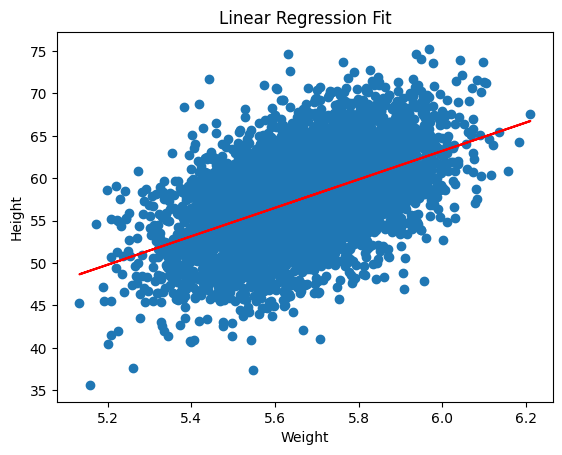

In [35]:
# 📈 Plot
plt.scatter(x_test, y_test)
plt.plot(x_test, y_pred, color='red')
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Linear Regression Fit")
plt.show()

In [36]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

## Results with Linear Regression ##
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Test data MSE:", mse)
print("Test Data RMSE:", rmse)
print("Test data R2 Score:", r2)

Test data MSE: 20.952882465721444
Test Data RMSE: 4.577431863580434
Test data R2 Score: 0.25137064208023696


In [37]:
## Apply Ridge Regression ##

ridge_model= Ridge()
ridge_model.fit(x_train, y_train)

# Predicted Value
y_pred_ridge = ridge_model.predict(x_test)

# Results with Ridge Regression
mse = mean_squared_error(y_test, y_pred_ridge)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_ridge)

print("Test data MSE:", mse)
print("Test Data RMSE:", rmse)
print("Test data R2 Score:", r2)

Test data MSE: 20.95316049710304
Test Data RMSE: 4.577462233279816
Test data R2 Score: 0.2513607082463112


In [38]:
## Apply Random Forest Regressor ##

rf_model= RandomForestRegressor()
rf_model.fit(x_train, y_train)

# Predicted Value
y_pred_rf = ridge_model.predict(x_test)

# Results with Ridge Regression
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("Test data MSE:", mse)
print("Test Data RMSE:", rmse)
print("Test data R2 Score:", r2)

Test data MSE: 20.95316049710304
Test Data RMSE: 4.577462233279816
Test data R2 Score: 0.2513607082463112


In [39]:
## Apply Decision Tree ##

dt_model= DecisionTreeRegressor()
dt_model.fit(x_train, y_train)

# Predicted Value
y_pred_dt = ridge_model.predict(x_test)

# Results with Ridge Regression
mse = mean_squared_error(y_test, y_pred_dt)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_dt)

print("Test data MSE:", mse)
print("Test Data RMSE:", rmse)
print("Test data R2 Score:", r2)

Test data MSE: 20.95316049710304
Test Data RMSE: 4.577462233279816
Test data R2 Score: 0.2513607082463112


In [40]:
# Height Value from User and Predicting weight value

x_user= float( input("Enter Height in Feet:"))

# Predict Weight of user
y_weight = LR_model.predict([[x_user]])
y_weight

# Final output
print("Your Predicted Weight is: ",y_weight,"\n\n\n\n")

Enter Height in Feet:8
Your Predicted Weight is:  [96.71199016] 






/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
